# 1. 数据准备

In [35]:
# ! wget https://www.dropbox.com/s/6l2vcvxl54b0b6w/food11.zip
# ! unzip food11.zip

# 2. 保证复现

In [36]:
import numpy as np
import torch
seed = 1
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(seed)
if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed_all(seed)
    print(f"使用{torch.cuda.get_device_name()}")
else:
    device = 'cpu'
    print(f"正在使用cpu")


使用NVIDIA RTX PRO 6000 Blackwell Server Edition


# 2. 定义Transform (图片处理)

In [37]:
from torchvision.transforms import transforms
# training_tfm = transforms.Compose([
#     transforms.Resize([224, 224]),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(30),
#     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet 归一化
# ])
training_tfm = transforms.Compose([
    # 先把图片放大一点，留出裁剪空间
    transforms.Resize([256, 256]),
    # 随机裁剪出 224x224，这等价于实现了平移和缩放的效果，且没有黑边
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    # 降低旋转角度，减轻模型从零学习的压力
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ================ TTA Tfm ================
tta_tfms = [transforms.Compose([
                transforms.Resize([224, 224]),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ]),
            transforms.Compose([
                transforms.Resize([224, 224]),
                transforms.RandomHorizontalFlip(p=1.0),  # 水平翻转
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ]),
            transforms.Compose([
                transforms.Resize([224, 224]),
                transforms.RandomVerticalFlip(p=1.0),  # 垂直翻转
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ]),
            transforms.Compose([
                transforms.Resize([224, 224]),
                transforms.RandomRotation(30),  # 旋转
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])]

# 3. Dataset 

In [38]:
from torch.utils.data import Dataset
import os
from PIL import Image
class FoodDataset(Dataset):
    def __init__(self, path, tfm = training_tfm, files = None):
        super().__init__()
        if files is not None:
            self.files = files
        else:
            self.files = sorted([os.path.join(path, x) for x in os.listdir(path) if x.endswith('.jpg')])
        self.tfm = tfm
        # print(self.files)
    def __getitem__(self,idx):
        im = Image.open(self.files[idx])
        im = self.tfm(im)
        try:
            data = im
            labels = int(self.files[idx].split('/')[-1].split('_')[0])
        except:
            labels = -1
        return data, labels       
    
    def __len__(self):
        return len(self.files)


In [39]:
trainset = FoodDataset('./food11/training',tfm=training_tfm)
validset = FoodDataset('./food11/validation', tfm=test_tfm)

# 4. 产生Dataloader

In [40]:
from torch.utils.data import DataLoader
batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(validset,batch_size=batch_size,shuffle=True, num_workers=8, pin_memory = True)
print(f"训练数据：{len(train_loader.dataset)}")
print(f"训练数据batch数量{len(train_loader)}")


训练数据：9866
训练数据batch数量39


# 5. Model

In [41]:
import torchvision
import torchvision.models as models
import torch.nn as nn
def make_model(num_class = 11):
    model = models.resnet50(pretrained = False)
    print(f"fc全连接 {model.fc}") ### fc是model（实例）的一个属性，与此同时本身也是一个实例（nn.Linear类实例化产生）
    print(f"{model.fc.in_features}")
    in_features = model.fc.in_features # 实例的属性fc，因为fc也是实例，也有属性in_features，最后in_features 也是属性 （int实例化出的）
    model.fc = nn.Linear(in_features, num_class) ### 重新实例化
    return model
model = make_model(11).to(device)
print(f"参数总量为 {sum([p.numel() for p in model.parameters() ])}") ###
print(f"需要梯度的参数总量 {sum([p.numel() for p in model.parameters() if p.requires_grad])}")


fc全连接 Linear(in_features=2048, out_features=1000, bias=True)
2048
参数总量为 23530571
需要梯度的参数总量 23530571


# 6. 定义损失和优化器

In [42]:
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(),lr = 0.01 ,weight_decay=1e-5) 
# # scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer,step_size=30,gamma=0.1)
# # scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer=optimizer, T_0= 10)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1) # 2026-04-15，17:15

# 引入标签平滑，缓解过拟合
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 使用 AdamW，初始学习率设为 0.001 (1e-3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4) 

# 余弦退火调度器：让学习率在 150 个 Epoch 内平滑过渡到接近 0
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# 7. 训练过程

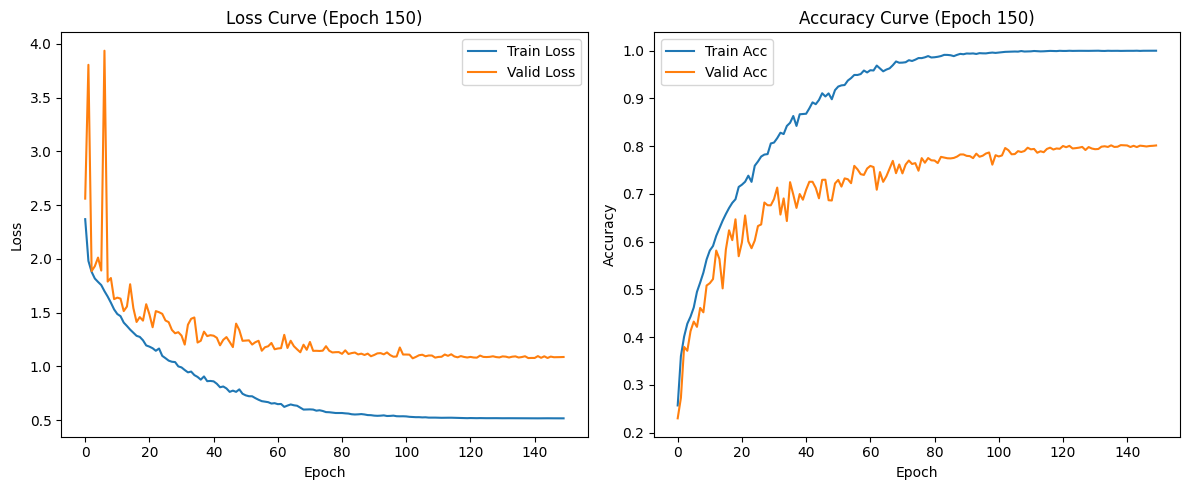

In [43]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
num_epochs = 150
count = 0
early_stop = 20
train_losses, train_accs, valid_losses, valid_accs = [], [], [], []
best_acc = 0
model_path = './models/model.pt'
if not os.path.exists('./models') :
    os.mkdir('./models')
for epoch in range(num_epochs):
    train_loss = 0
    train_acc = 0
    model.train()
    for _, batch in enumerate(tqdm(train_loader)):
        features, labels = batch
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
        optimizer.step()
        _, pred = torch.max(logits, dim = 1)
        train_loss += loss.detach().cpu().item()
        train_acc += (pred.detach() == labels).float().mean().item()
    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    if len(valid_loader) > 0:
        model.eval()
        valid_loss = 0
        valid_acc = 0
        with torch.no_grad():
            for _, batch in enumerate(tqdm(valid_loader)):
                features, labels = batch
                features, labels = features.to(device), labels.to(device)
                logits = model(features)
                loss = criterion(logits, labels)
                _, pred = torch.max(logits, dim = 1)
                valid_loss += loss.item()
                valid_acc += (pred == labels).float().mean().item()
            valid_loss /= len(valid_loader)
            valid_acc /= len(valid_loader)
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)

        if valid_acc > best_acc:
            best_acc = valid_acc
            torch.save(model.state_dict(), f = model_path)
            print(f"Saving model with best acc {best_acc}...")
            count = 0
        else:
            count += 1
            if count >= early_stop:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']
    print(f"Learning Rate: {cur_lr:.6f}")

    # ===== 每隔 10 个 epoch 刷新一次图 =====
    if (epoch + 1) % 1 == 0 or epoch == 0:
        clear_output(wait=True)   # 清掉上一个图，不重刷整个页面
        
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        if valid_losses:
            plt.plot(valid_losses, label='Valid Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'Loss Curve (Epoch {epoch+1})')
        
        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Train Acc')
        if valid_accs:
            plt.plot(valid_accs, label='Valid Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title(f'Accuracy Curve (Epoch {epoch+1})')
        
        plt.tight_layout()
        plt.show()

# 8. 加载最优模型和预测

In [44]:
def predict_with_tta(model, image_path, tfms):
    model.eval()
    image = Image.open(image_path)
    predictions = []
    
    with torch.no_grad():
        # print(f'总共使用了 {len(tfms)} 个 TTA 变换')
        for tfm in tfms:
            transformed_image = tfm(image).unsqueeze(0).to(device)  # 添加 batch 维度并移动到设备
            logits = model(transformed_image) ### 获取模型输出的 batch_size x num_classes 的 logits
            predictions.append(logits.cpu().numpy()) ### 列表里每一个元素是一个 batch_size x num_classes 的 numpy 数组
    avg_prediction = np.mean(predictions, axis=0)  # 对所有预测结果取平均  变成一个 num_classes 的 numpy 数组
    predicted_label = np.argmax(avg_prediction)  # 获取平均预测结果的类别
    return predicted_label 

In [45]:
del model
model = make_model(11).to(device)
model.load_state_dict(torch.load(f = './models/model.pt'))
testdata = FoodDataset('./food11/test',tfm=test_tfm)
testloader = DataLoader(testdata, batch_size= batch_size, shuffle= False, num_workers=4, pin_memory=True)
preds = []
image_paths = sorted([os.path.join('./food11/test', x) for x in os.listdir('./food11/test') if x.endswith('.jpg')])
for image_path in tqdm(image_paths):
    pred_label = predict_with_tta(model, image_path, tta_tfms)
    preds.append(pred_label) 
predictions_detach = np.array(preds)
import pandas as pd
df = pd.DataFrame({"Id": [os.path.basename(x) for x in image_paths], "Category": predictions_detach})
### 去掉jpg
df['Id'] = df['Id'].str.replace('.jpg', '')

df.to_csv('./submission.csv', index=False)

fc全连接 Linear(in_features=2048, out_features=1000, bias=True)
2048


100%|██████████| 3347/3347 [00:44<00:00, 74.73it/s]
